## 1.不同粒度模型剪枝实践

按照剪枝粒度进行划分，剪枝可分为细粒度剪枝（Fine-grained Pruning）、基于模式的剪枝（Pattern-based Pruning）、向量级剪枝（Vector-level Pruning）、内核级剪枝（Kernel-level Pruning）与通道级剪枝（Channel-level Pruning）。

如下图所示，展示了从细粒度剪枝到通道级的剪枝，剪枝越来越规则和结构化。

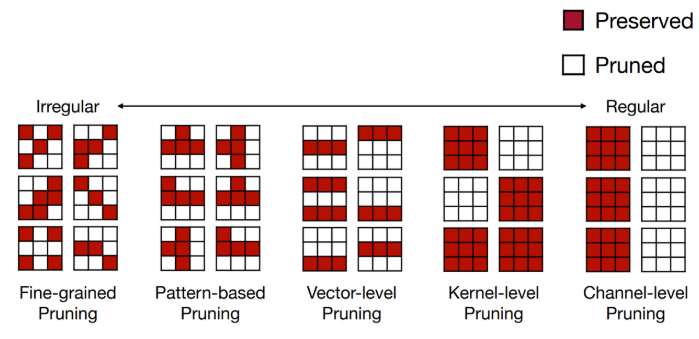

下面将分别用一些简单的例子来举例说明。

In [1]:
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文乱码
#plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']

In [2]:
# 可视化2维矩阵函数，将值为0的元素与其他元素通过不同颜色区分开
# tensor，输入的二维张量。
# title，图像的标题。
def plot_tensor(tensor, title):
    # 创建一个新的图像和轴
    fig, ax = plt.subplots()
    
    # tensor.cpu().numpy() == 0检查tensor中的每个元素是否为0，生成一个布尔矩阵（True表示该位置为0，False表示非0）。
    # imshow函数用于显示生成的布尔矩阵，并通过颜色映射表tab20c区分True和False位置，即将tensor中的0值和非0值用不同颜色区分开。
    ax.imshow(tensor.cpu().numpy() == 0, vmin=0, vmax=1, cmap='tab20c')
    ax.set_title(title)
    ax.set_yticklabels([])  # 清除y轴刻度标签
    ax.set_xticklabels([])  # 清除x轴刻度标签
    
    # 遍历矩阵中的每个元素并添加文本标签
    for i in range(tensor.shape[1]):
        for j in range(tensor.shape[0]):
            text = ax.text(j, i, f'{tensor[i, j].item():.2f}', ha="center", va="center", color="k")
    
    # 显示图像
    plt.show()


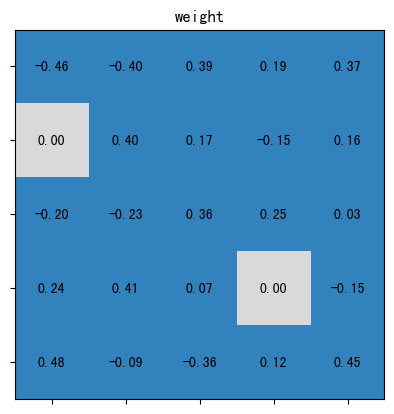

In [3]:
# 测试效果
weight=torch.tensor([[-0.46, -0.40, 0.39, 0.19, 0.37],
                            [0.00, 0.40, 0.17, -0.15, 0.16],
                            [-0.20, -0.23, 0.36, 0.25, 0.03],
                            [0.24, 0.41, 0.07, 0.00, -0.15],
                            [0.48, -0.09, -0.36, 0.12, 0.45]])
plot_tensor(weight, 'weight')

## 细粒度剪枝

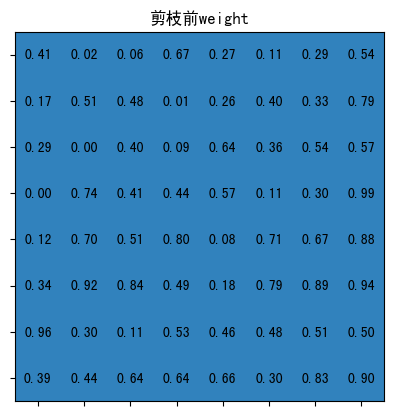

In [4]:
# 创建一个矩阵weight
weight = torch.rand(8, 8)
plot_tensor(weight, '剪枝前weight')

现在定义一个规则，比如想要将Tensor里的值小于0.5的都置为0

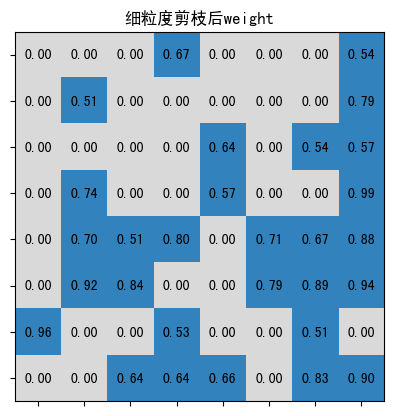

In [5]:
# 细粒度剪枝方法1
# 将tensor中小于threshold的元素设置为0
def _fine_grained_prune(tensor: torch.Tensor, threshold  : float) -> torch.Tensor:
    """
    :param tensor: 输入张量，包含需要剪枝的权重。
    :param threshold: 阈值，用于判断权重的大小。
    :return: 剪枝后的张量。
    """
    for i in range(tensor.shape[1]):
        for j in range(tensor.shape[0]):
            if tensor[i, j] < threshold:
                tensor[i][j] = 0
    return tensor

pruned_weight = _fine_grained_prune(weight, 0.5) # 将tensor中小于0.5的元素设置为0
plot_tensor(weight, '细粒度剪枝后weight')

可能会有同学按照上述代码用for循环遍历去实现，虽然结果是对的，但如果参数太大的话，肯定会影响到速度，下面将介绍在剪枝中常用的一种方法，即使用mask掩码矩阵来实现。

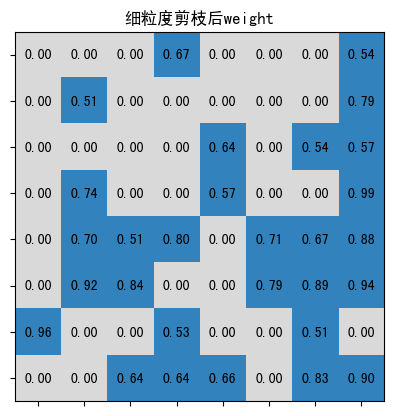

In [6]:
# 细粒度剪枝方法2
def fine_grained_prune(tensor: torch.Tensor, threshold  : float) -> torch.Tensor:
    """
    创建一个掩码张量，指示哪些权重不应被剪枝（应保持非零）。

    :param tensor: 输入张量，包含需要剪枝的权重。
    :param threshold: 阈值，用于判断权重的大小。
    :return: 剪枝后的张量。
    """

    # gt是"greater than"的缩写，表示比较操作。对于tensor中的每个元素，如果其值大于threshold，则对应位置的掩码值为True；否则为 False。
    # 结果是一个布尔张量（mask），形状与tensor相同。
    mask = torch.gt(tensor, threshold)

    # mul_是原地乘法操作，会直接修改tensor。在PyTorch中，布尔值可以自动转换为整数：True转换为1，False转换为0。
    # 因此，tensor.mul_(mask)等价于将tensor中小于等于threshold的元素置为0，而大于threshold的元素保持不变。
    tensor.mul_(mask)

    return tensor

pruned_weight = fine_grained_prune(weight, 0.5)
plot_tensor(pruned_weight, '细粒度剪枝后weight')

## 基于模式的剪枝

这里以NVIDIA 2：4为例，创建一个patterns，如下图所示，由于是2:4，即从4个中取出2个置为0，可以算出一共有6种不同的模式；

然后将weight matrix变换成nx4的格式方便与pattern进行矩阵运算，运算后的结果为nx6的矩阵，在n的维度上进行argmax取得最大的索引(索引对应pattern)，然后将索引对应的pattern值填充到mask中。

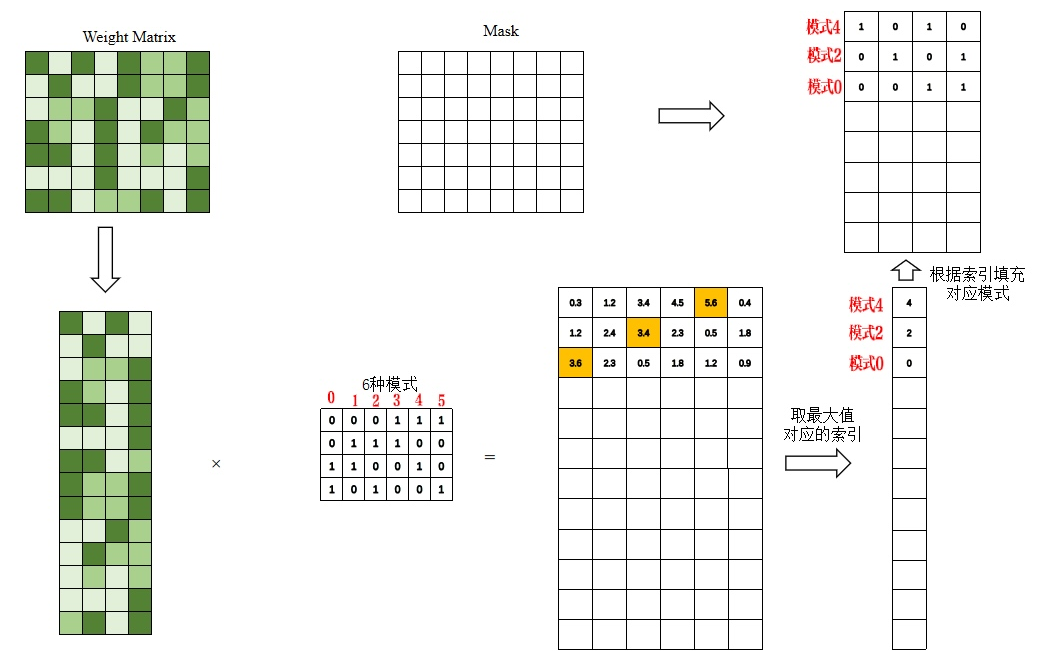

1、给定Weight Matrix，要求pattern为n:m，例如2:4。  

2、目标是求出一个mask，其形状与Weight Matrix相同，其值不是0就是1。求出mask后，与Weight Matrix做mul_（原地乘法）操作，直接修改Weight Matrix，将Weight Matrix中对应mask为0的位置设置为0，而对应mask为1的位置保持不变。  

3、为了求mask矩阵。先求出n:m的pattern有多少可能的排列，假设有y种排列，所有排列组成一个pattern张量，则其形状为m:y。例如，对于2:4的pattern，有6种可能的排列，所以得到一个4x6的张量。  

4、初始时mask值全部初始化为1，然后将mask的形状转换为x:m，与pattern做矩阵乘法，得到一个x:y的矩阵，对于x行中的每一行，选择值最大的那个，代表得分最高的pattern。这样就可以映射到一个x:m的张量，再把这个x:m的张量的形状转换为原始的mask的形状，就得到mask，其值不是0就是1。  

5、得到mask后，与Weight Matrix做mul_（原地乘法）操作，直接修改Weight Matrix，将Weight Matrix中对应mask为0的位置设置为0，而对应mask为1的位置保持不变。这样就完成了对Weight Matrix的模式剪枝。  

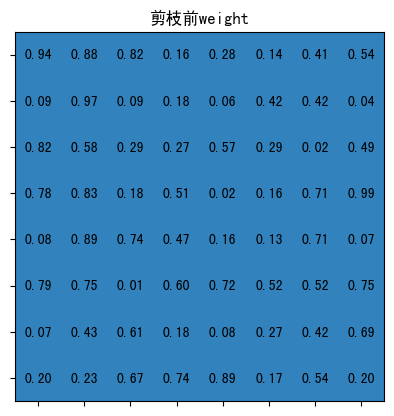

In [7]:
# 创建一个矩阵weight
weight = torch.rand(8, 8)
plot_tensor(weight, '剪枝前weight')

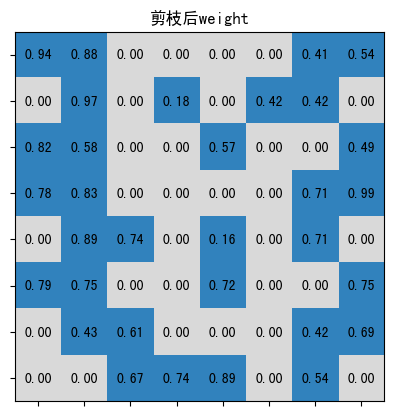

In [8]:
from itertools import permutations

# 将tensor转换成列为m的格式，若不能整除m则填充0
def reshape_1d(tensor, m):
    if tensor.shape[1] % m > 0:
        # 创建一个新的张量mat，其形状为(tensor.shape[0], 新的列数)。
        # 新的列数为tensor.shape[1] + (m - tensor.shape[1] % m)，即在原列数的基础上增加必要的填充列数，以确保总列数能被m整除。
        # 使用.fill_(0)将mat的所有元素初始化为0。
        mat = torch.FloatTensor(tensor.shape[0], tensor.shape[1] + (m - tensor.shape[1] % m)).fill_(0)
        
        # 将原始张量tensor的数据复制到新张量mat的前tensor.shape[1]列中。其余列保持为0填充部分）。
        mat[:, : tensor.shape[1]] = tensor

        # 将张量重新调整为形状(p, m)，其中p是新的行数。-1表示自动计算行数，使得总的元素数量保持不变。
        return mat.view(-1, m)
    else:
        # 如果输入张量的列数已经能被m整除，则直接使用view方法调整形状为(p, m)。
        return tensor.view(-1, m)

# 用于生成所有可能的长度为m的一维模式，其中前n个元素为1，其余为0。
# m: 模式的总长度。
# n: 前 n 个元素为 1，其余为 0。
def compute_valid_1d_patterns(m, n):
    # 创建一个长度为m的全零张量patterns。
    patterns = torch.zeros(m)

    # 将patterns的前n个元素设置为1，其余保持为0。
    patterns[:n] = 1

    # patterns.tolist(): 将patterns转换为Python列表，以便后续处理。
    # 使用itertools.permutations生成所有可能的排列。
    # 使用set去重，确保只保留唯一的排列（因为某些排列可能是重复的）。
    # list将去重后的集合转换为列表。
    # torch.Tensor将列表转换为PyTorch张量，方便后续操作。
    valid_patterns = torch.Tensor(list(set(permutations(patterns.tolist()))))

    # 返回包含所有唯一的一维模式的张量。
    return valid_patterns

# 根据输入张量tensor和参数m、n，计算一个掩码张量（mask）。
# 掩码的作用是保留每组m个元素中最重要的n个元素，其余的元素被置为0。
def compute_mask(tensor, m, n):
    # 调用上面定义的compute_valid_1d_patterns函数，计算所有可能的模式
    patterns = compute_valid_1d_patterns(m,n)

    # torch.IntTensor(tensor.shape).fill_(1)创建一个与tensor形状相同的整数张量，并将其所有元素初始化为1。
    # .view(-1, m)将张量重新调整为形状(p, m)，其中p是新的行数。
    mask = torch.IntTensor(tensor.shape).fill_(1).view(-1,m)

    # 调用上面定义的reshape_1d函数将输入张量tensor调整为形状(p, m)。如果tensor的列数不能被m整除，则会通过填充零补齐。
    mat = reshape_1d(tensor, m)

    # mat.abs()对mat中的每个元素取绝对值，确保只考虑权重的大小而不考虑符号。
    # patterns.t()是patterns的转置，形状为(m, k)，其中k是模式的数量。
    # torch.matmul(mat.abs(), patterns.t())计算每组数据与所有模式的匹配得分。
    # 矩阵乘法的结果是一个形状为(p, k)的张量，表示每组数据与每个模式的匹配得分。
    # torch.argmax(..., dim=1)对每组数据找到匹配得分最高的模式索引。
    # pmax是一个形状为(p,)的张量，表示每组数据的最佳模式索引。
    pmax = torch.argmax(torch.matmul(mat.abs(), patterns.t()), dim=1)

    # 使用pmax中的索引从patterns中选择对应的模式。将这些模式赋值给mask，覆盖原先的全1值。
    mask[:] = patterns[pmax[:]]

    # 将mask从形状(p, m)恢复为原始形状tensor.shape。
    mask = mask.view(tensor.shape)

    return mask

# 对输入张量tensor进行模式剪枝（Pattern Pruning）。模式剪枝的核心思想是通过生成一个掩码（mask），保留每组m个元素中最重要的n个元素，其余的元素被置为0。
def pattern_pruning(tensor, m, n):
    # 调用compute_mask 函数生成掩码张量mask。
    mask = compute_mask(weight, m, n)

    # mul_是原地乘法操作，会直接修改tensor。将tensor中对应mask为0的位置设置为0，而对应mask为1的位置保持不变。
    tensor.mul_(mask)

    return tensor

# 调用pattern_pruning函数执行模式剪枝。
pruned_weight = pattern_pruning(weight, 4, 2)

# 可视化剪枝结果。
plot_tensor(pruned_weight, '剪枝后weight')

## 向量级别剪枝

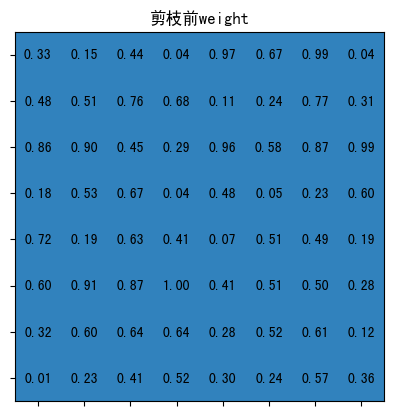

In [9]:
# 创建一个矩阵weight
weight = torch.rand(8, 8)
plot_tensor(weight, '剪枝前weight')

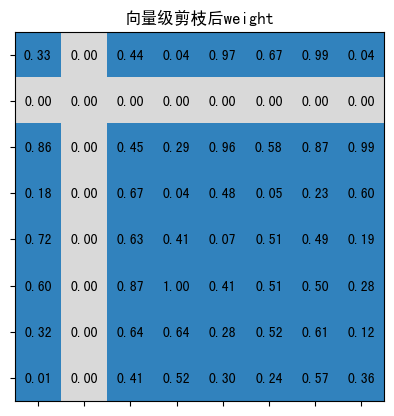

In [10]:
# 剪枝某个点所在的行与列
def vector_pruning(weight, point):
    row, col = point

    # 使用clone()方法创建weight的副本prune_weight。这是为了避免直接修改原始矩阵weight，确保原始数据不会被破坏。
    prune_weight = weight.clone()

    # 将prune_weight中第row行的所有元素置为0。
    prune_weight[row, :] = 0
    
    # 将prune_weight中第col列的所有元素置为0。
    prune_weight[:, col] = 0

    return prune_weight

point = (1, 1)
prune_weight = vector_pruning(weight, point)
plot_tensor(prune_weight, '向量级剪枝后weight')

## 卷积核级别剪枝

In [11]:
# 定义可视化4维张量的函数
def visualize_tensor(tensor, title, batch_spacing=3):
    fig = plt.figure()  # 创建一个新的matplotlib图形
    ax = fig.add_subplot(111, projection='3d')  # 向图形中添加一个3D子图

    # 遍历张量的批次维度
    for batch in range(tensor.shape[0]):
        # 遍历张量的通道维度
        for channel in range(tensor.shape[1]):
            # 遍历张量的高度维度
            for i in range(tensor.shape[2]):
                # 遍历张量的宽度维度
                for j in range(tensor.shape[3]):
                    # 计算条形的x位置，考虑到不同批次间的间隔
                    # j表示当前元素在宽度维度上的位置。
                    # (batch * (tensor.shape[3] + batch_spacing))是为了在不同批次之间添加间距，这样可以避免不同批次的条形重叠。
                    x = j + (batch * (tensor.shape[3] + batch_spacing))
                    y = i  # 条形的y位置，即张量的高度维度
                    z = channel  # 条形的z位置，即张量的通道维度
                    # 如果张量在当前位置的值为0，则设置条形颜色为红色，否则为绿色
                    color = 'red' if tensor[batch, channel, i, j] == 0 else 'green'
                    # 绘制单个3D条形
                    ax.bar3d(x, y, z, 1, 1, 1, shade=True, color=color, edgecolor='black', alpha=0.9)

    ax.set_title(title)  # 设置3D图形的标题
    ax.set_xlabel('Width')  # 设置x轴标签，对应张量的宽度维度
    ax.set_ylabel('Height')  # 设置y轴标签，对应张量的高度维度
    ax.set_zlabel('Channel')  # 设置z轴标签，对于张量的通道维度
    ax.set_zlim(ax.get_zlim()[::-1])  # 反转z轴方向
    ax.zaxis.labelpad = 15  # 调整z轴标签的填充

    plt.show()  # 显示图形


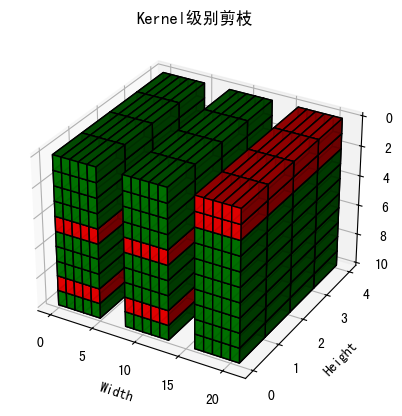

In [12]:
def prune_conv_layer(conv_layer, prune_method,title="", percentile=0.2, vis=True):
    # 创建输入张量的副本，避免修改原始数据。
    prune_layer = conv_layer.clone()

    l2_norm = None
    mask = None

    # 使用torch.norm计算卷积核的L2范数，沿最后两个维度（高度和宽度）进行归约。
    # 注意，这里是计算卷积核的L2范数，而不是计算prune_layer的L2范数。
    # prune_layer的形状是(3, 10, 4, 5)，而torch.norm是对(4, 5)这个卷积核计算L2范数。
    l2_norm = torch.norm(prune_layer, p=2, dim=(-2, -1), keepdim=True)

    # 通过torch.quantile计算L2范数的百分位数，作为剪枝的阈值。
    threshold = torch.quantile(l2_norm, percentile)

    # 创建布尔掩码mask，标记哪些卷积核的L2范数大于阈值。
    mask = l2_norm > threshold

    # 将掩码应用于原始张量，将低于阈值的卷积核置零。
    prune_layer = prune_layer * mask.float()
    
    # 调用visualize_tensor函数可视化剪枝后的张量。
    visualize_tensor(prune_layer,title=prune_method)  

# 使用PyTorch创建一个张量
tensor = torch.rand((3, 10, 4, 5))

# 调用函数进行剪枝
pruned_tensor = prune_conv_layer(tensor, 'Kernel级别剪枝', vis=True)


## Filter级别剪枝

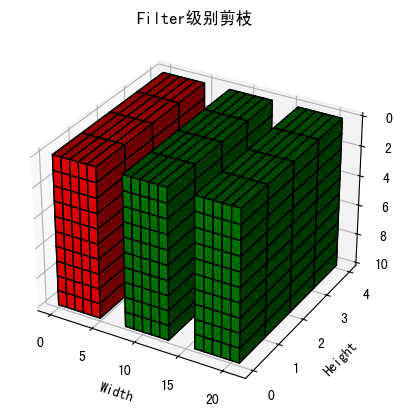

In [13]:
def prune_conv_layer(conv_layer, prune_method,title="", percentile=0.2, vis=True):
    # 使用clone()方法创建输入张量的副本，避免修改原始数据。
    prune_layer = conv_layer.clone()

    l2_norm = None
    mask = None

    # torch.norm沿着维度(1, 2, 3)归约，计算每个Filter的L2范数。
    l2_norm = torch.norm(prune_layer, p=2, dim=(1, 2, 3), keepdim=True)

    # 使用torch.quantile计算l2_norm的百分位数作为剪枝阈值。
    # 例如，percentile=0.2表示保留L2范数最大的80%的Filters。
    threshold = torch.quantile(l2_norm, percentile)

    # mask是一个布尔张量，表示哪些Filters的L2范数大于阈值（需要保留）。
    mask = l2_norm > threshold

    # 将掩码应用于原始张量，将低于阈值的Filters置零。
    prune_layer = prune_layer * mask.float()
    
    # 调用visualize_tensor函数可视化剪枝后的张量。
    visualize_tensor(prune_layer,title=prune_method)  

# 使用PyTorch创建一个张量
tensor = torch.rand((3, 10, 4, 5))

# 调用函数进行剪枝
pruned_tensor = prune_conv_layer(tensor, 'Filter级别剪枝', vis=True)

## Channel级别剪枝

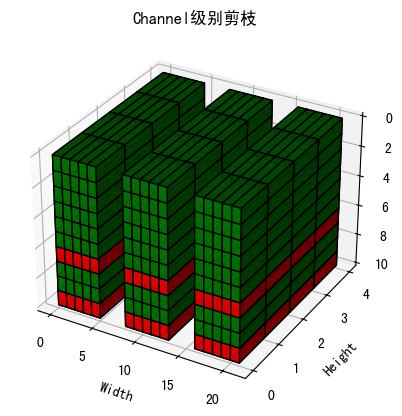

In [14]:
def prune_conv_layer(conv_layer, prune_method,title="", percentile=0.2, vis=True):
    # 使用clone()方法创建输入张量的副本，避免修改原始数据。
    prune_layer = conv_layer.clone()

    l2_norm = None
    mask = None

    # torch.norm沿着维度(0, 2, 3)归约，计算每个Channel的L2范数。
    l2_norm = torch.norm(prune_layer, p=2, dim=(0, 2, 3), keepdim=True)

    # 使用torch.quantile计算l2_norm的百分位数作为剪枝阈值。例如，percentile=0.2表示保留L2范数最大的80%的Channels。
    threshold = torch.quantile(l2_norm, percentile)

    # mask是一个布尔张量，表示哪些Channels的L2范数大于阈值（需要保留）。
    mask = l2_norm > threshold

    # 将掩码应用于原始张量，将低于阈值的Channels置零。
    prune_layer = prune_layer * mask.float()
    
    # 调用visualize_tensor函数可视化剪枝后的张量。
    visualize_tensor(prune_layer,title=prune_method)  

# 使用PyTorch创建一个张量
tensor = torch.rand((3, 10, 4, 5))

# 调用函数进行剪枝
pruned_tensor = prune_conv_layer(tensor, 'Channel级别剪枝', vis=True)

## 汇总
下面用3D的可视化方式对所有的剪枝方法对一个对比。

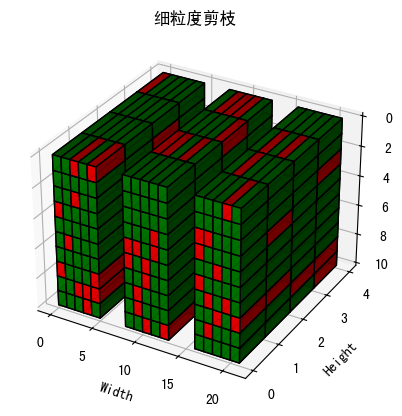

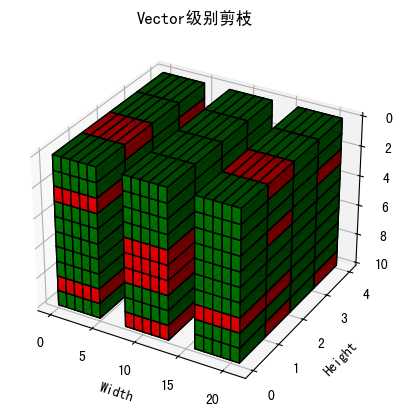

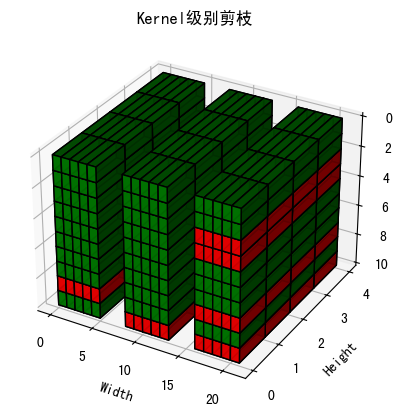

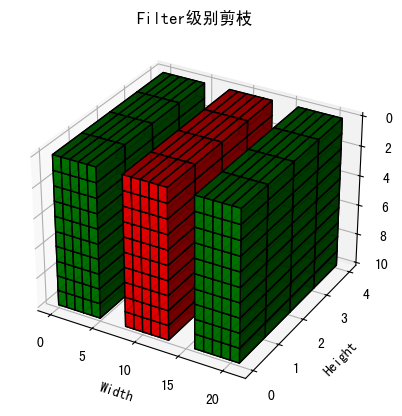

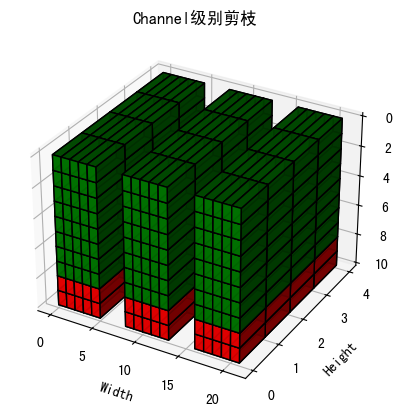

In [15]:
# 计算给定范数张量norms的阈值，返回一个布尔掩码，标记哪些元素的范数大于阈值。
def get_threshold_and_mask(norms, percentile):
    threshold = torch.quantile(norms, percentile)
    return norms > threshold

# 根据指定的剪枝方法（prune_method）对卷积层进行剪枝。
def prune_conv_layer(conv_layer, prune_method, title= "", percentile=0.2, vis=True):
    # 使用clone()方法创建输入张量的副本，避免修改原始数据。
    prune_layer = conv_layer.clone()

    mask = None
    if prune_method == "fine_grained":
        prune_layer[torch.abs(prune_layer) < percentile] = 0
    elif prune_method == "vector_level":
        mask = get_threshold_and_mask(torch.norm(prune_layer, p=2, dim=-1), percentile).unsqueeze(-1)
    elif prune_method == "kernel_level":
        mask = get_threshold_and_mask(torch.norm(prune_layer, p=2, dim=(-2, -1), keepdim=True), percentile)
    elif prune_method == "filter_level":
        mask = get_threshold_and_mask(torch.norm(prune_layer, p=2, dim=(1, 2, 3), keepdim=True), percentile)
    elif prune_method == "channel_level":
        mask = get_threshold_and_mask(torch.norm(prune_layer, p=2, dim=(0, 2, 3), keepdim=True), percentile)

    # 如果生成了掩码，则将其应用于原始张量，将低于阈值的部分置零。
    if mask is not None:
        prune_layer = prune_layer * mask.float()

    # 如果vis=True，调用visualize_tensor函数可视化剪枝后的张量。
    if vis:
        visualize_tensor(prune_layer, title=title)  # 实现可视化的函数

    return prune_layer

# 使用PyTorch创建一个张量
tensor = torch.rand((3, 10, 4, 5)) 

# 调用函数进行剪枝
pruned_tensor = prune_conv_layer(tensor, 'fine_grained', '细粒度剪枝',  vis=True)
pruned_tensor = prune_conv_layer(tensor, 'vector_level', 'Vector级别剪枝', vis=True)
pruned_tensor = prune_conv_layer(tensor, 'kernel_level', 'Kernel级别剪枝', vis=True)
pruned_tensor = prune_conv_layer(tensor, 'filter_level', 'Filter级别剪枝', vis=True)
pruned_tensor = prune_conv_layer(tensor, 'channel_level', 'Channel级别剪枝', vis=True)

